# Credit Card Approval Prediction

https://www.kaggle.com/datasets/rikdifos/credit-card-approval-prediction

In [1]:
# preprocessing
import pandas as pd
import numpy as np

# missing value chart
import missingno

# graph
import matplotlib.pyplot as plt
import seaborn as sns

# sampling
from imblearn.over_sampling import SMOTE
from imblearn.under_sampling import RandomUnderSampler

import warnings
warnings.filterwarnings('ignore') 

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV

# ML - model
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from catboost import CatBoostClassifier

# DL
from sklearn.neural_network import MLPClassifier


SEED = 22


In [2]:
base = pd.read_csv("data/application_record.csv", encoding = 'utf-8') 
record = pd.read_csv("data/credit_record.csv", encoding = 'utf-8')

In [3]:
base.head()


,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [4]:
base.shape

(438557, 18)

In [5]:
record.head()

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C


In [6]:
record.shape

(1048575, 3)

# Create Target

record table의 정보를 통해서 어떤 이용자가 신용이 불량한지 확인하고,
이를 통해 훈련에 사용할 Target데이터를 완성

record table - 속성정보

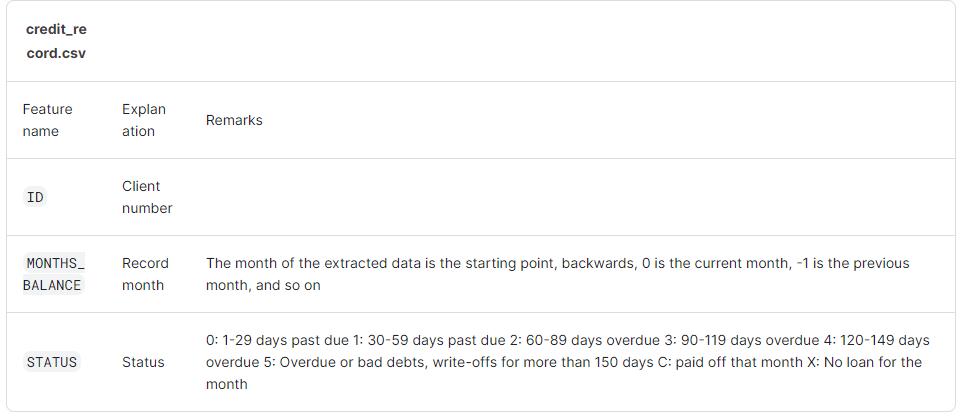

status를 통해서 신용상태를 확인

0 / 1 / 2 / 3 / 4 / 5

In [7]:
record['STATUS'].value_counts()

STATUS
C    442031
0    383120
X    209230
1     11090
5      1693
2       868
3       320
4       223
Name: count, dtype: int64

In [8]:
record.head(20)

,ID,MONTHS_BALANCE,STATUS
0,5001711,0,X
1,5001711,-1,0
2,5001711,-2,0
3,5001711,-3,0
4,5001712,0,C
5,5001712,-1,C
6,5001712,-2,C
7,5001712,-3,C
8,5001712,-4,C
9,5001712,-5,C


In [9]:
record['ID'].nunique()

45985

In [10]:
record.drop(columns='MONTHS_BALANCE', inplace=True)

In [11]:
record_0 = record[record['STATUS'] == '0'].groupby('ID').count().rename(columns={'STATUS' : 'status0'})
record_1 = record[record['STATUS'] == '1'].groupby('ID').count().rename(columns={'STATUS' : 'status1'})
record_2 = record[record['STATUS'] == '2'].groupby('ID').count().rename(columns={'STATUS' : 'status2'})
record_3 = record[record['STATUS'] == '3'].groupby('ID').count().rename(columns={'STATUS' : 'status3'})
record_4 = record[record['STATUS'] == '4'].groupby('ID').count().rename(columns={'STATUS' : 'status4'})
record_5 = record[record['STATUS'] == '5'].groupby('ID').count().rename(columns={'STATUS' : 'status5'})
record_C = record[record['STATUS'] == 'C'].groupby('ID').count().rename(columns={'STATUS' : 'statusC'})
record_X = record[record['STATUS'] == 'X'].groupby('ID').count().rename(columns={'STATUS' : 'statusX'})

In [12]:
record_count = pd.merge(record_0, record_1, on='ID', how='outer')
record_count = pd.merge(record_count, record_2, on='ID', how='outer')
record_count = pd.merge(record_count, record_3, on='ID', how='outer')
record_count = pd.merge(record_count, record_4, on='ID', how='outer')
record_count = pd.merge(record_count, record_5, on='ID', how='outer')
record_count = pd.merge(record_count, record_C, on='ID', how='outer')
record_count = pd.merge(record_count, record_X, on='ID', how='outer')
record_count


,status0,status1,status2,status3,status4,status5,statusC,statusX
ID,,,,,,,,
5001711,3.0,NaN,NaN,NaN,NaN,NaN,NaN,1.0
5001712,10.0,NaN,NaN,NaN,NaN,NaN,9.0,NaN
5001713,NaN,NaN,NaN,NaN,NaN,NaN,NaN,22.0
5001714,NaN,NaN,NaN,NaN,NaN,NaN,NaN,15.0
5001715,NaN,NaN,NaN,NaN,NaN,NaN,NaN,60.0
...,...,...,...,...,...,...,...,...
5150482,12.0,NaN,NaN,NaN,NaN,NaN,6.0,NaN
5150483,NaN,NaN,NaN,NaN,NaN,NaN,NaN,18.0
5150484,12.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN


In [13]:
record_count = record_count.fillna(0)
record_count

,status0,status1,status2,status3,status4,status5,statusC,statusX
ID,,,,,,,,
5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0
5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0
5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0
5001714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0
5001715,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0
...,...,...,...,...,...,...,...,...
5150482,12.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0
5150483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0
5150484,12.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


In [14]:
record_count['total_status'] = record_count.sum(axis=1)
record_count

,status0,status1,status2,status3,status4,status5,statusC,statusX,total_status
ID,,,,,,,,,
5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,19.0
5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,22.0
5001714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,15.0
5001715,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,60.0
...,...,...,...,...,...,...,...,...,...
5150482,12.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,18.0
5150483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,18.0
5150484,12.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0


In [15]:
record_count.reset_index(inplace=True)

In [16]:
record_count

,ID,status0,status1,status2,status3,status4,status5,statusC,statusX,total_status
0,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0
1,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,19.0
2,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,22.0
3,5001714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,15.0
4,5001715,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,60.0
...,...,...,...,...,...,...,...,...,...,...
45980,5150482,12.0,0.0,0.0,0.0,0.0,0.0,6.0,0.0,18.0
45981,5150483,0.0,0.0,0.0,0.0,0.0,0.0,0.0,18.0,18.0
45982,5150484,12.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,13.0
45983,5150485,2.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,2.0


In [17]:
record_count['ID'].nunique()

45985

In [18]:
#  연체가 발생한 경우 - 40032 건
record_count[(record_count['status0'] > 0) |
             (record_count['status1'] > 0) |
             (record_count['status2'] > 0) |
             (record_count['status3'] > 0) |
             (record_count['status4'] > 0) |
             (record_count['status5'] > 0) ].shape[0]

40032

In [19]:
#  한달이상 연체가 발생한 경우 - 5350 건
record_count[(record_count['status1'] > 0) |
             (record_count['status2'] > 0) |
             (record_count['status3'] > 0) |
             (record_count['status4'] > 0) |
             (record_count['status5'] > 0) ].shape[0]

5350

In [20]:
#  두달이상 연체가 발생한 경우 - 667 건
record_count[(record_count['status2'] > 0) |
             (record_count['status3'] > 0) |
             (record_count['status4'] > 0) |
             (record_count['status5'] > 0) ].shape[0]

667

In [21]:
#  세달이상 연체가 발생한 경우 - 331 건
record_count[(record_count['status3'] > 0) |
             (record_count['status4'] > 0) |
             (record_count['status5'] > 0) ].shape[0]

331

In [22]:
## 신용카드 연체의 기준이 90일 이상이니  status 3 / 4 / 5 만 사용 -> 331건
## 데이터의 숫자가 부족하니까 60이상 667건으로 사용할지
## 데이터의 숫자가 부족하니까 30이상 5350건으로 사용할지

In [23]:
# record_count['over30'] = record_count['status1'] + record_count['status2'] + record_count['status3'] + record_count['status4'] + record_count['status5']
# record_count['over60'] = record_count['status2'] + record_count['status3'] + record_count['status4'] + record_count['status5']
# record_count['over90'] = record_count['status3'] + record_count['status4'] + record_count['status5']

In [24]:
#각 값이 0이면 0 1이상이면 1로

record_count['over30'] = (record_count.iloc[:, 2:7].sum(axis=1) > 0).astype(int)
record_count['over60'] = (record_count.iloc[:, 3:7].sum(axis=1) > 0).astype(int)
record_count['over90'] = (record_count.iloc[:, 4:7].sum(axis=1) > 0).astype(int)

In [25]:
record_count.head(10)

,ID,status0,status1,status2,status3,status4,status5,statusC,statusX,total_status,over30,over60,over90
0,5001711,3.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,4.0,0,0,0
1,5001712,10.0,0.0,0.0,0.0,0.0,0.0,9.0,0.0,19.0,0,0,0
2,5001713,0.0,0.0,0.0,0.0,0.0,0.0,0.0,22.0,22.0,0,0,0
3,5001714,0.0,0.0,0.0,0.0,0.0,0.0,0.0,15.0,15.0,0,0,0
4,5001715,0.0,0.0,0.0,0.0,0.0,0.0,0.0,60.0,60.0,0,0,0
5,5001717,17.0,0.0,0.0,0.0,0.0,0.0,5.0,0.0,22.0,0,0,0
6,5001718,24.0,2.0,0.0,0.0,0.0,0.0,3.0,10.0,39.0,1,0,0
7,5001719,2.0,0.0,0.0,0.0,0.0,0.0,41.0,0.0,43.0,0,0,0
8,5001720,29.0,7.0,0.0,0.0,0.0,0.0,0.0,0.0,36.0,1,0,0
9,5001723,8.0,0.0,0.0,0.0,0.0,0.0,0.0,23.0,31.0,0,0,0


In [26]:
df_target = record_count[['ID', 'over30', 'over60', 'over90']]
df_target.head()

,ID,over30,over60,over90
0,5001711,0,0,0
1,5001712,0,0,0
2,5001713,0,0,0
3,5001714,0,0,0
4,5001715,0,0,0


In [27]:
df_target.over30.value_counts(())

over30
0    40635
1     5350
Name: count, dtype: int64

In [28]:
df_target['ID']

0        5001711
1        5001712
2        5001713
3        5001714
4        5001715
          ...   
45980    5150482
45981    5150483
45982    5150484
45983    5150485
45984    5150487
Name: ID, Length: 45985, dtype: int64

In [29]:
base.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,DAYS_BIRTH,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,-12005,-4542,1,1,0,0,NaN,2.0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,-21474,-1134,1,0,0,0,Security staff,2.0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,-19110,-3051,1,0,1,1,Sales staff,1.0


In [30]:
df = pd.merge(base, df_target, how = 'inner', on = 'ID')
df.head()

,ID,CODE_GENDER,FLAG_OWN_CAR,FLAG_OWN_REALTY,CNT_CHILDREN,AMT_INCOME_TOTAL,NAME_INCOME_TYPE,NAME_EDUCATION_TYPE,NAME_FAMILY_STATUS,NAME_HOUSING_TYPE,...,DAYS_EMPLOYED,FLAG_MOBIL,FLAG_WORK_PHONE,FLAG_PHONE,FLAG_EMAIL,OCCUPATION_TYPE,CNT_FAM_MEMBERS,over30,over60,over90
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,1,0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,1,0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,-1134,1,0,0,0,Security staff,2.0,0,0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,0,0,0


In [31]:
df_target['ID'].nunique()

45985

In [32]:
df.shape

(36457, 21)

In [33]:
## base data 

In [34]:
df = df.rename(columns={
    'CODE_GENDER':'gender',
    'FLAG_OWN_CAR':'own_car',
    'FLAG_OWN_REALTY':'own_house',
    'CNT_CHILDREN':'children',
    'AMT_INCOME_TOTAL':'inc',
    'NAME_INCOME_TYPE':'employment',
    'NAME_EDUCATION_TYPE':'edu',
    'NAME_FAMILY_STATUS':'marry',
    'NAME_HOUSING_TYPE':'house_type',
    'DAYS_BIRTH':'age',
    'DAYS_EMPLOYED': 'employ_length',
    'FLAG_MOBIL': 'own_mobile',
    'FLAG_WORK_PHONE': 'own_workphone',
    'FLAG_PHONE': 'own_phone',
    'FLAG_EMAIL': 'own_email',
    'OCCUPATION_TYPE': 'job',
    'CNT_FAM_MEMBERS': 'family'
    })

In [35]:
df.head(5)

,ID,gender,own_car,own_house,children,inc,employment,edu,marry,house_type,...,employ_length,own_mobile,own_workphone,own_phone,own_email,job,family,over30,over60,over90
0,5008804,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,1,0,0
1,5008805,M,Y,Y,0,427500.0,Working,Higher education,Civil marriage,Rented apartment,...,-4542,1,1,0,0,NaN,2.0,1,0,0
2,5008806,M,Y,Y,0,112500.0,Working,Secondary / secondary special,Married,House / apartment,...,-1134,1,0,0,0,Security staff,2.0,0,0,0
3,5008808,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,0,0,0
4,5008809,F,N,Y,0,270000.0,Commercial associate,Secondary / secondary special,Single / not married,House / apartment,...,-3051,1,0,1,1,Sales staff,1.0,0,0,0


In [36]:
df.shape

(36457, 21)

In [37]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 21 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   ID             36457 non-null  int64  
 1   gender         36457 non-null  object 
 2   own_car        36457 non-null  object 
 3   own_house      36457 non-null  object 
 4   children       36457 non-null  int64  
 5   inc            36457 non-null  float64
 6   employment     36457 non-null  object 
 7   edu            36457 non-null  object 
 8   marry          36457 non-null  object 
 9   house_type     36457 non-null  object 
 10  age            36457 non-null  int64  
 11  employ_length  36457 non-null  int64  
 12  own_mobile     36457 non-null  int64  
 13  own_workphone  36457 non-null  int64  
 14  own_phone      36457 non-null  int64  
 15  own_email      36457 non-null  int64  
 16  job            25134 non-null  object 
 17  family         36457 non-null  float64
 18  over30

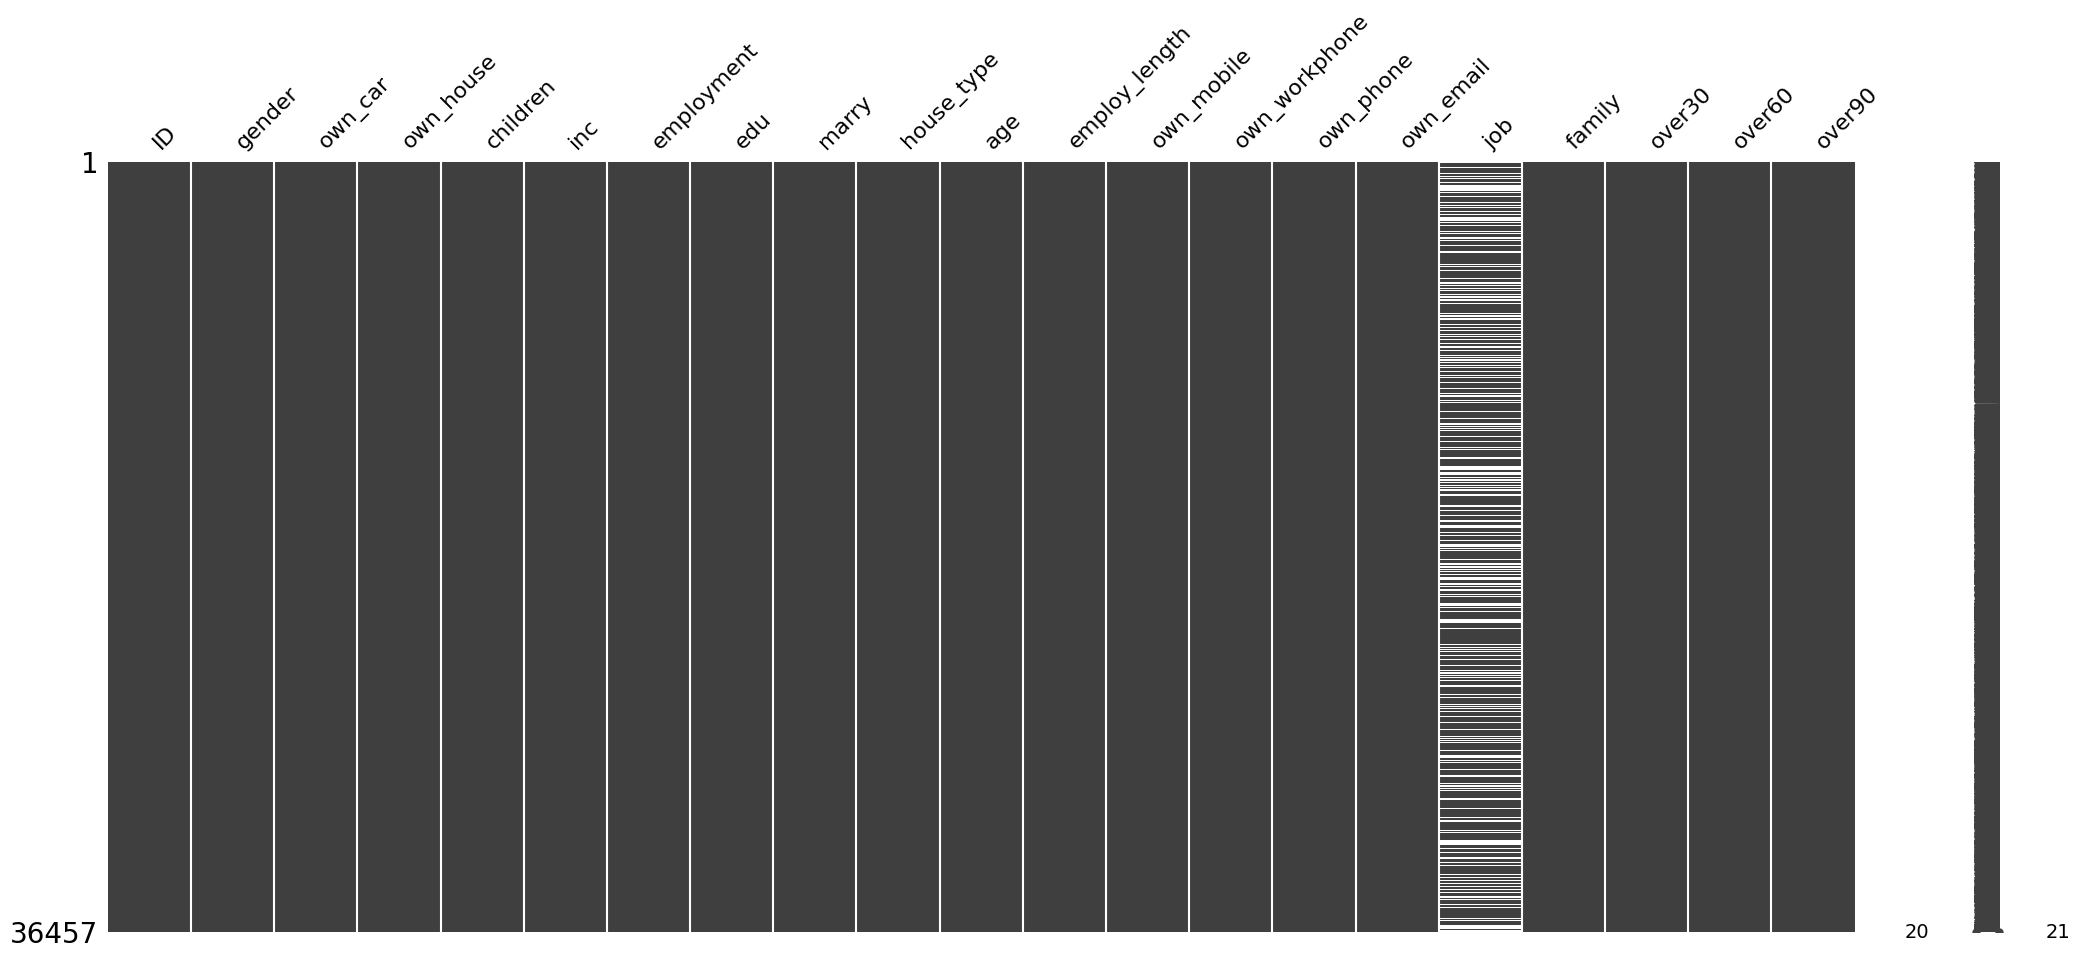

In [38]:
missingno.matrix(df)
plt.show()
## job feature 에만 NA존재

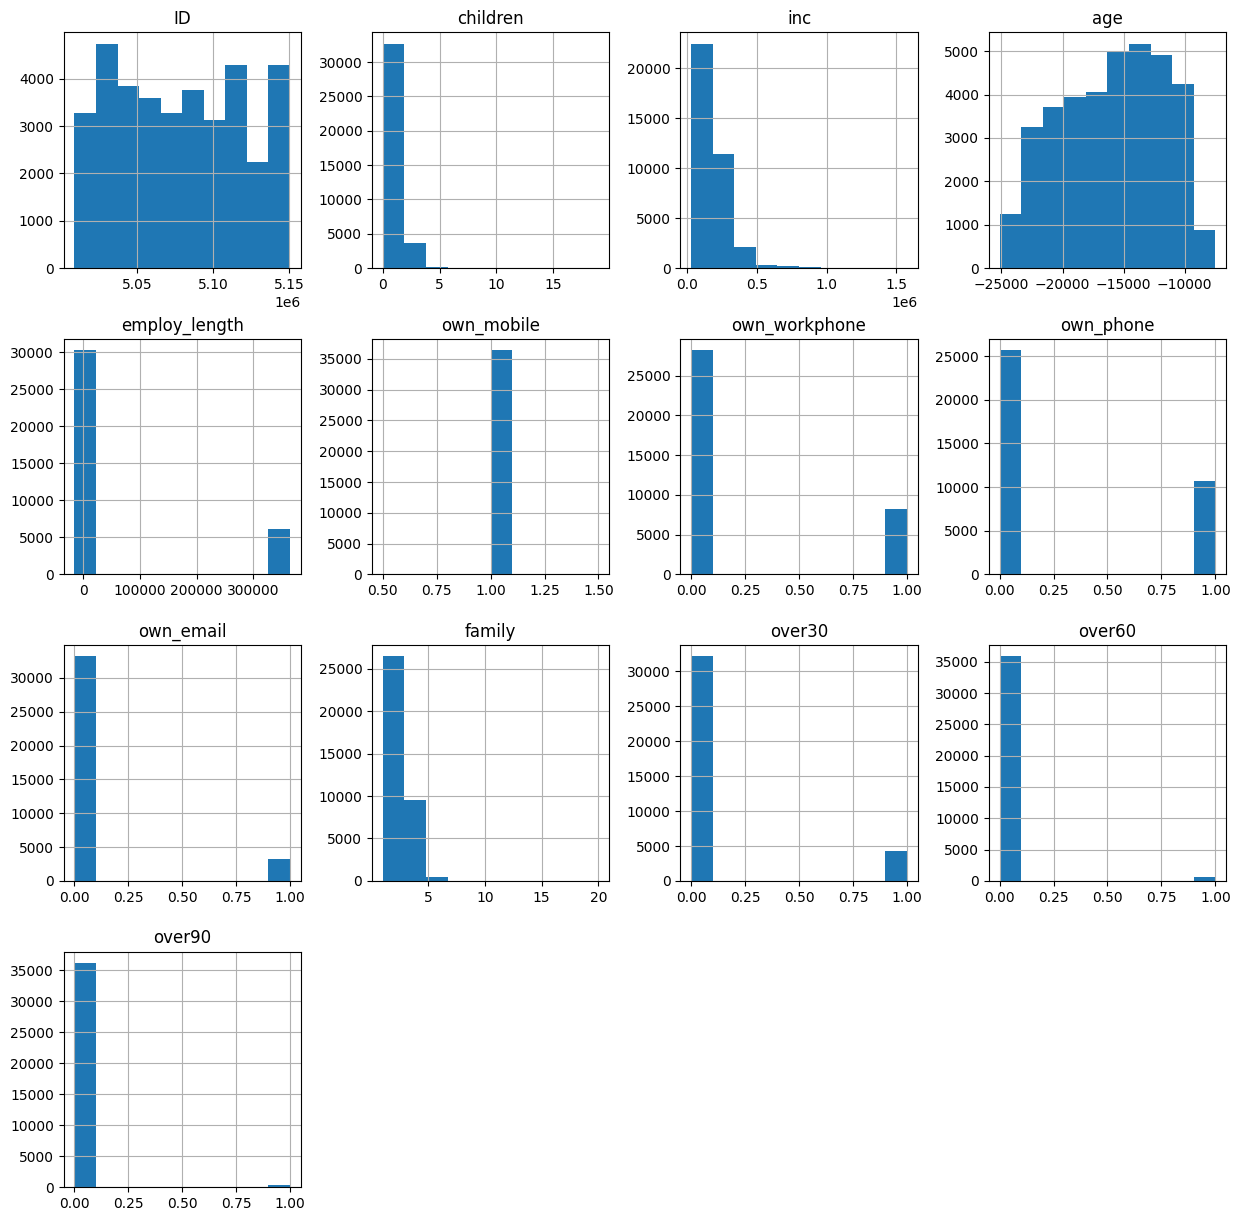

In [39]:
plt.rc('axes', labelsize=14, titlesize=12)
plt.rc('legend', fontsize=14)

df.hist(figsize=(15, 15))
#plt.savefig('image/numric.png')
plt.show()

In [40]:
binominal_val = ['gender', 'own_car', 'own_house',  'own_mobile', 'own_workphone', 'own_phone', 'own_email', ]
cateorical_val = ['edu', 'marry', 'house_type', 'job',  'employment']
numeric_val = ['age', 'employ_length', 'family', 'inc',  'children']


In [41]:
len(binominal_val) +  len(cateorical_val) + len(numeric_val)

17

In [42]:
len(df.columns)

21

In [43]:
df.columns

Index(['ID', 'gender', 'own_car', 'own_house', 'children', 'inc', 'employment',
       'edu', 'marry', 'house_type', 'age', 'employ_length', 'own_mobile',
       'own_workphone', 'own_phone', 'own_email', 'job', 'family', 'over30',
       'over60', 'over90'],
      dtype='object')

In [44]:
### numeric feature

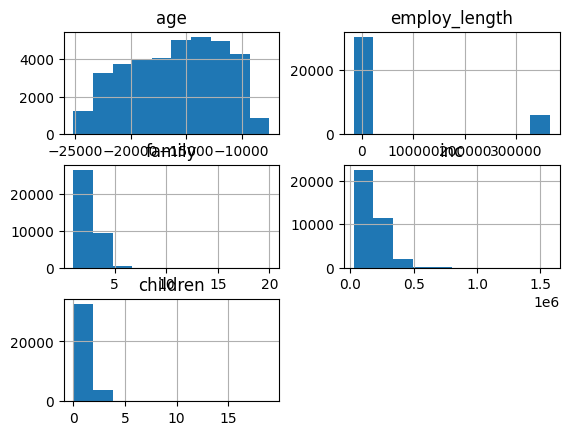

In [45]:
plt.rc('axes', labelsize=14, titlesize=12)
plt.rc('legend', fontsize=14)

df[numeric_val].hist()

plt.savefig('image/numric.png')
#plt.show()


In [46]:
# age - Birthday	Count backwards from current day (0), -1 means yesterday

# age를 절대값으로 바꾸고, 연나이로 바꾸고
#  floor 함수 적용
df['age'] = df['age'].apply(lambda x : np.floor(abs(x) / 365))

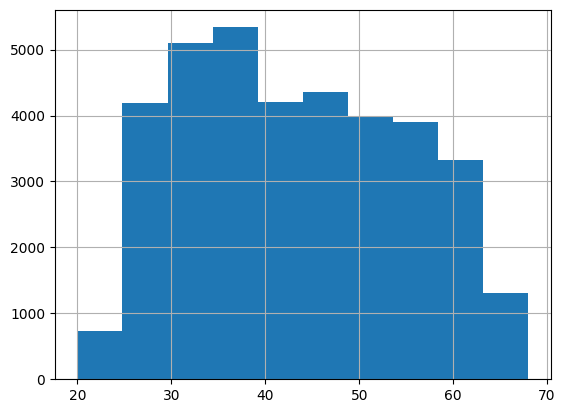

In [47]:
df['age'].hist()
plt.show()

In [48]:
# employ_length - Count backwards from current day(0). If positive, it means the person currently unemployed.

df['employ_length'].value_counts()

employ_length
 365243    6135
-401         78
-1539        64
-200         63
-1678        61
           ... 
-4686         1
-2160         1
-2007         1
-758          1
-11272        1
Name: count, Length: 3640, dtype: int64

1.763642389842931


<Axes: >

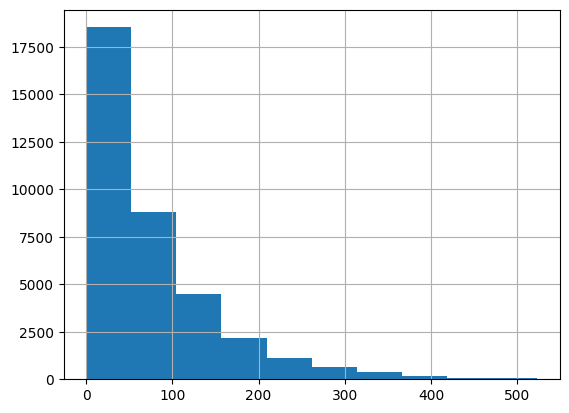

In [49]:
df['employ_length'] = df['employ_length'].apply(lambda x: np.floor(abs(x) / 30) if x < 0 else 0)
print(df['employ_length'].skew())
df['employ_length'].hist()

<Axes: >

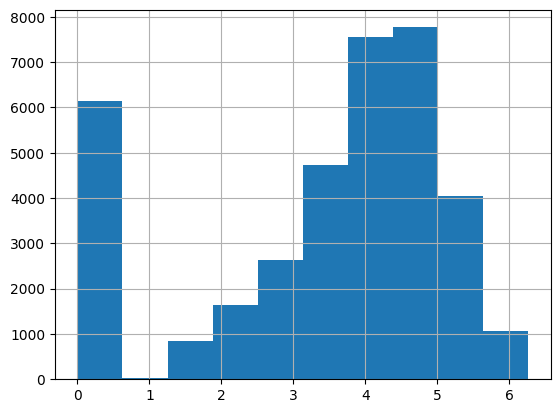

In [50]:
# skewness를 해결하기 위해서 log변환

df['employ_length'] = df['employ_length'].apply(lambda x: np.log(x + 1))
df['employ_length'].hist()

<Axes: >

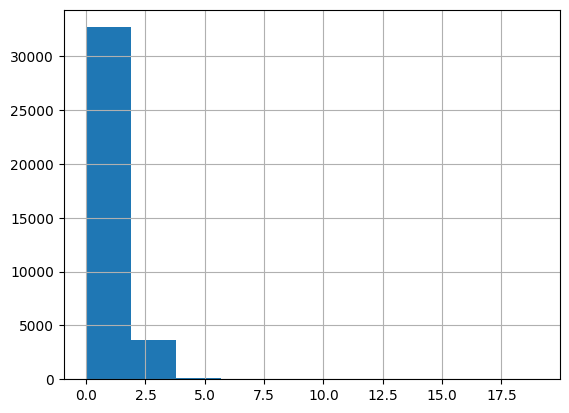

In [51]:
## children

df['children'].hist()

In [52]:
df['children'].value_counts()

children
0     25201
1      7492
2      3256
3       419
4        63
5        20
14        3
7         2
19        1
Name: count, dtype: int64

In [53]:
## 3이상인 경우 

print(df[df['children'] >= 3].shape[0])
print(f"자녀수가 3이상인 경우는 전체의 {round((df[df['children'] >= 3].shape[0]) / df.shape[0] * 100, 2)}%")


508
자녀수가 3이상인 경우는 전체의 1.39%


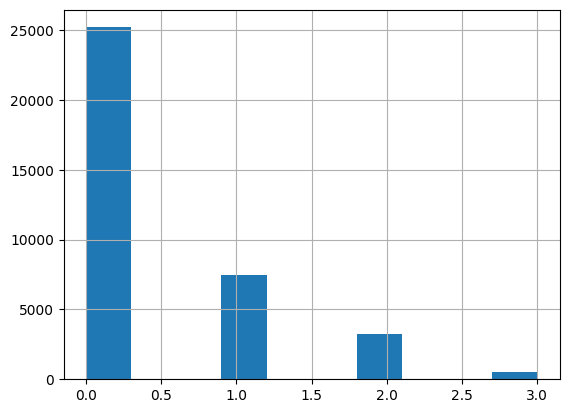

In [54]:
# 3이상을 하나의 카테고리로 변환

df['children'] = df['children'].apply(lambda x: x if x < 3 else 3)
df['children'].hist()
plt.show()

In [55]:
# family

df['family'].value_counts()

family
2.0     19463
1.0      6987
3.0      6421
4.0      3106
5.0       397
6.0        58
7.0        19
15.0        3
9.0         2
20.0        1
Name: count, dtype: int64

In [56]:
## 5이상인 경우 

print(df[df['family'] >= 5].shape[0])
print(f"자녀수가 5이상인 경우는 전체의 {round((df[df['family'] >= 5].shape[0]) / df.shape[0] * 100, 2)}%")

480
자녀수가 5이상인 경우는 전체의 1.32%


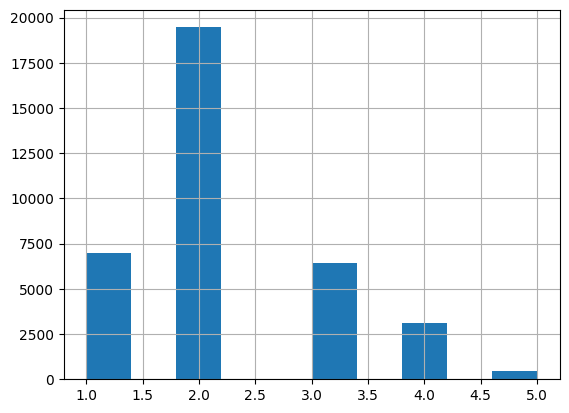

In [57]:
# 5이상을 하나의 카테고리로 변환

df['family'] = df['family'].apply(lambda x: x if x < 5 else 5)
df['family'].hist()
plt.show()

In [58]:
### inc

In [59]:
df['inc'].unique()

array([ 427500. ,  112500. ,  270000. ,  283500. ,  135000. ,  130500. ,
        157500. ,  405000. ,  211500. ,  360000. ,  126000. ,  315000. ,
        247500. ,  297000. ,  225000. ,  166500. ,  216000. ,  255150. ,
        148500. ,  202500. ,   94500. ,  450000. ,  180000. ,   90000. ,
        765000. ,  382500. ,  144000. ,  229500. ,  292500. ,   74250. ,
         40500. ,  337500. ,  193500. ,  267750. ,  139500. ,   67500. ,
        252000. ,  900000. ,  115290. ,  279000. ,   76500. ,  234000. ,
         81000. ,  108000. ,   99000. ,  198000. ,   45000. ,  238500. ,
        117000. ,  153000. , 1350000. ,  445500. ,  495000. ,   85500. ,
        306000. ,  562500. ,  189000. ,  328500. ,  310500. ,  540000. ,
        171000. ,  675000. ,  121500. ,   72000. ,   65250. ,  184500. ,
        103500. ,  162000. ,  165150. ,   54000. ,  243000. ,  256500. ,
         33300. ,  697500. ,  101250. ,   58500. ,  110250. ,  472500. ,
        196650. ,  630000. ,  432000. ,  257625. , 

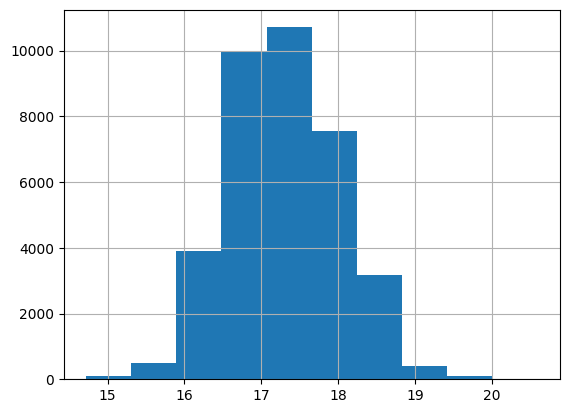

In [60]:
# inc_log 변환

df['inc'] = np.log2(df['inc'])
df['inc'].hist()
plt.show()

In [61]:
df['inc']

0        18.705565
1        18.705565
2        16.779565
3        18.042600
4        18.042600
           ...    
36452    18.264992
36453    17.264992
36454    17.264992
36455    18.112989
36456    16.779565
Name: inc, Length: 36457, dtype: float64

In [62]:
binominal_val = ['gender', 'own_car', 'own_house',  'own_mobile', 'own_workphone', 'own_phone', 'own_email', ]
cateorical_val = ['edu', 'marry', 'house_type', 'job',  'employment']

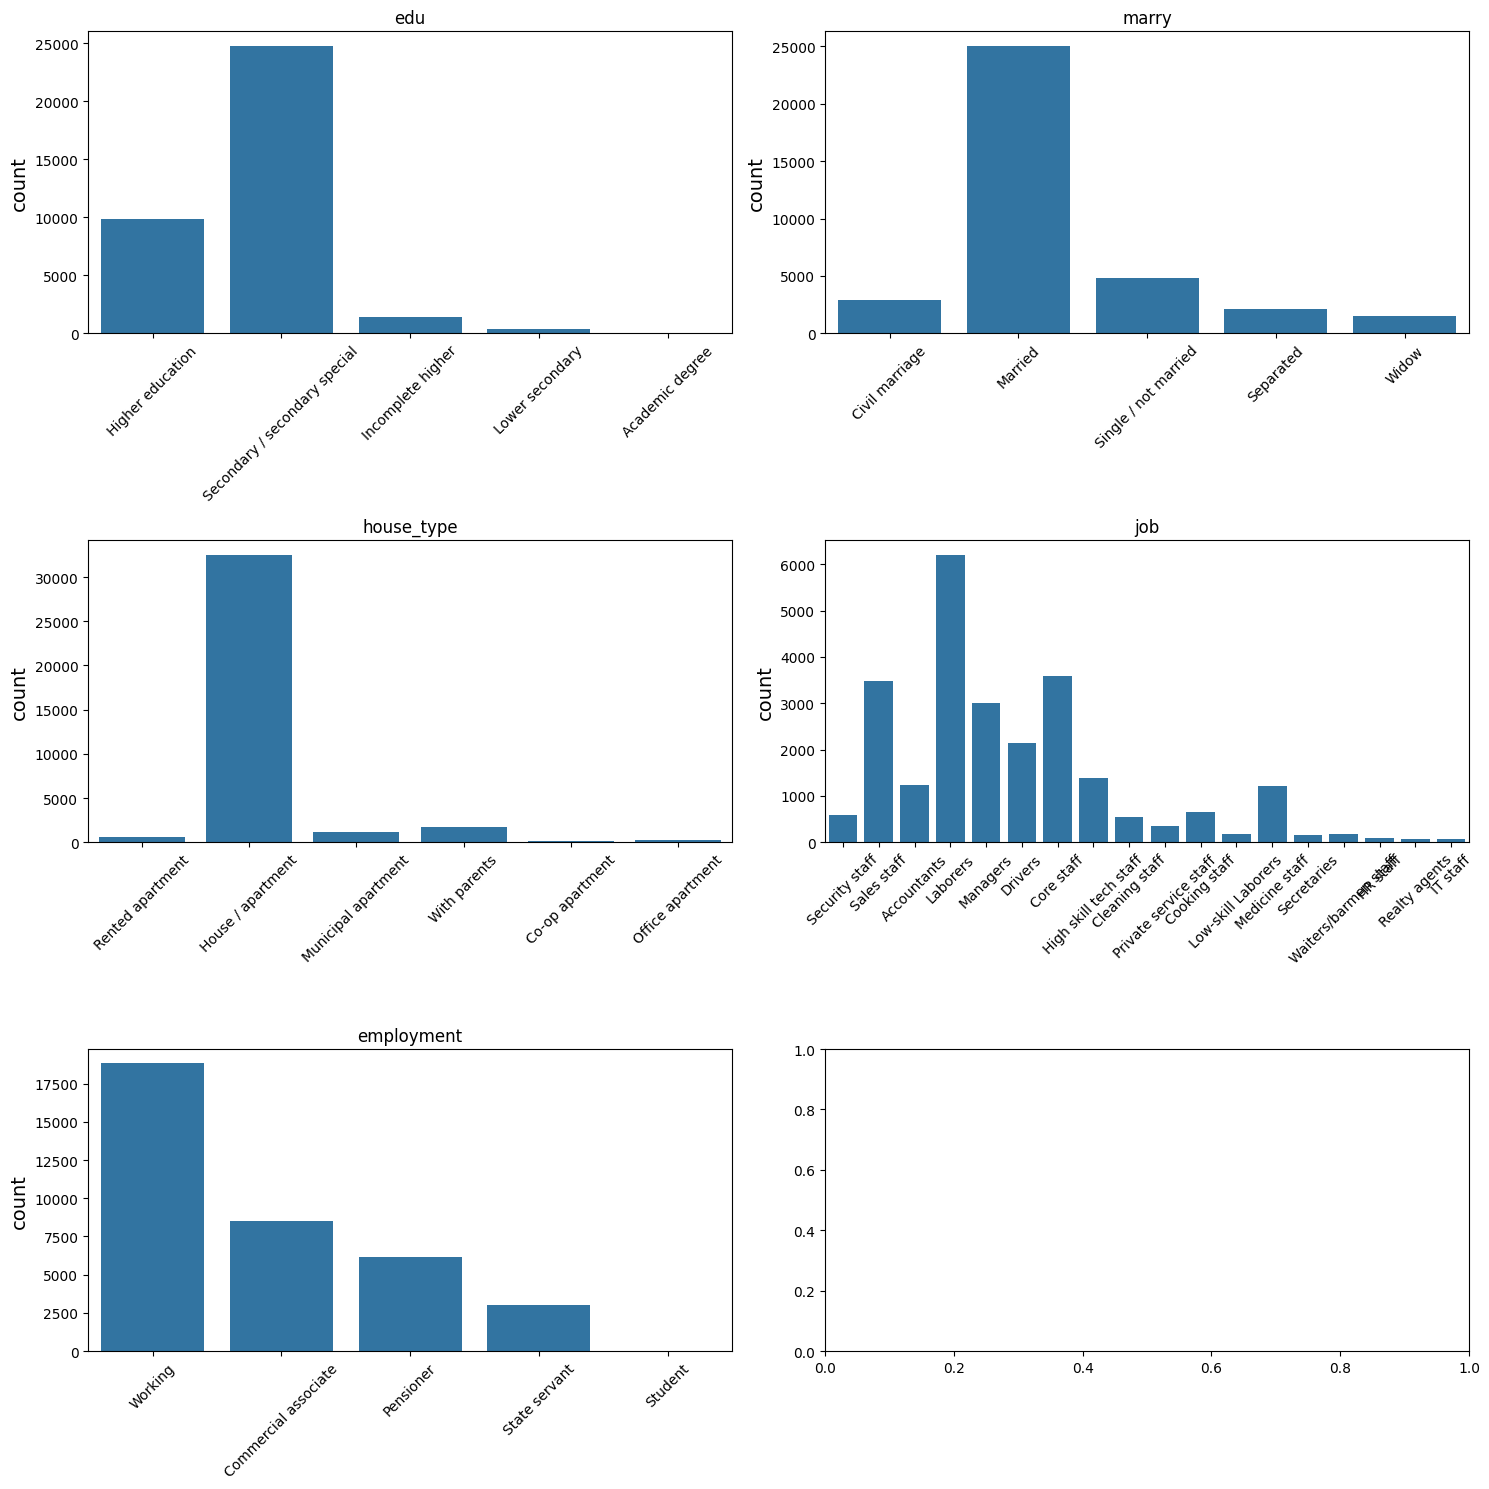

In [63]:

f, axes = plt.subplots(3, 2, figsize=(15, 15))

for i, column in enumerate(cateorical_val):
    sns.countplot(data=df, x=column, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(column)  # 각 subplot에 제목 설정
    axes[i//2, i%2].set_xlabel('')
    axes[i//2, i%2].tick_params(axis='x', rotation=45)  # x축 눈금 회전

plt.tight_layout()  # 서브플롯 간의 간격 조정
plt.savefig('image/category.png')
#plt.show()

In [64]:
## categorical feature 이름 바꾸기?

In [65]:
#cateorical_val[0]

In [66]:
#df['edu'].unique()

In [67]:
# # 교육 수준에 따라 새로운 라벨 정의
# edu_level = {
#     'Lower secondary': 0,
#     'Secondary / secondary special': 1,
#     'Incomplete higher': 2,
#     'Higher education': 3,
#     'Academic degree': 4
# }

# # 'education' 열의 라벨을 새로운 라벨로 변경
# df['edu'].map(edu_level)

In [68]:
# df['edu']

In [69]:
# df['edu'] = df['edu'].map(edu_level)
# df['edu']

In [70]:
# cateorical_val[1]

In [71]:
# marry

In [72]:
# df['marry'].unique()

In [73]:
# # 가족 형태에 따라 새로운 라벨 정의
# marry_level = {
#     'Married': 0,
#     'Single / not married': 1,
#     'Civil marriage': 2,        
#     'Separated': 3,
#     'Widow': 4
# }

# # 'family_status' 열의 라벨을 새로운 라벨로 변경
# df['marry'] = df['marry'].map(marry_level)

In [74]:
# cateorical_val[2]

In [75]:
# df['house_type'].unique()

In [76]:
# house_level = {
#     'Rented apartment': 0,
#     'House / apartment': 1,
#     'Municipal apartment': 2,
#     'With parents': 3,
#     'Co-op apartment': 4,
#     'Office apartment': 5
# }

# # 'housing_type' 열의 라벨을 새로운 라벨로 변경
# df['house_type'] = df['house_type'].map(house_level)

In [77]:
# cateorical_val[3]

In [78]:
# df['house_type'].unique()

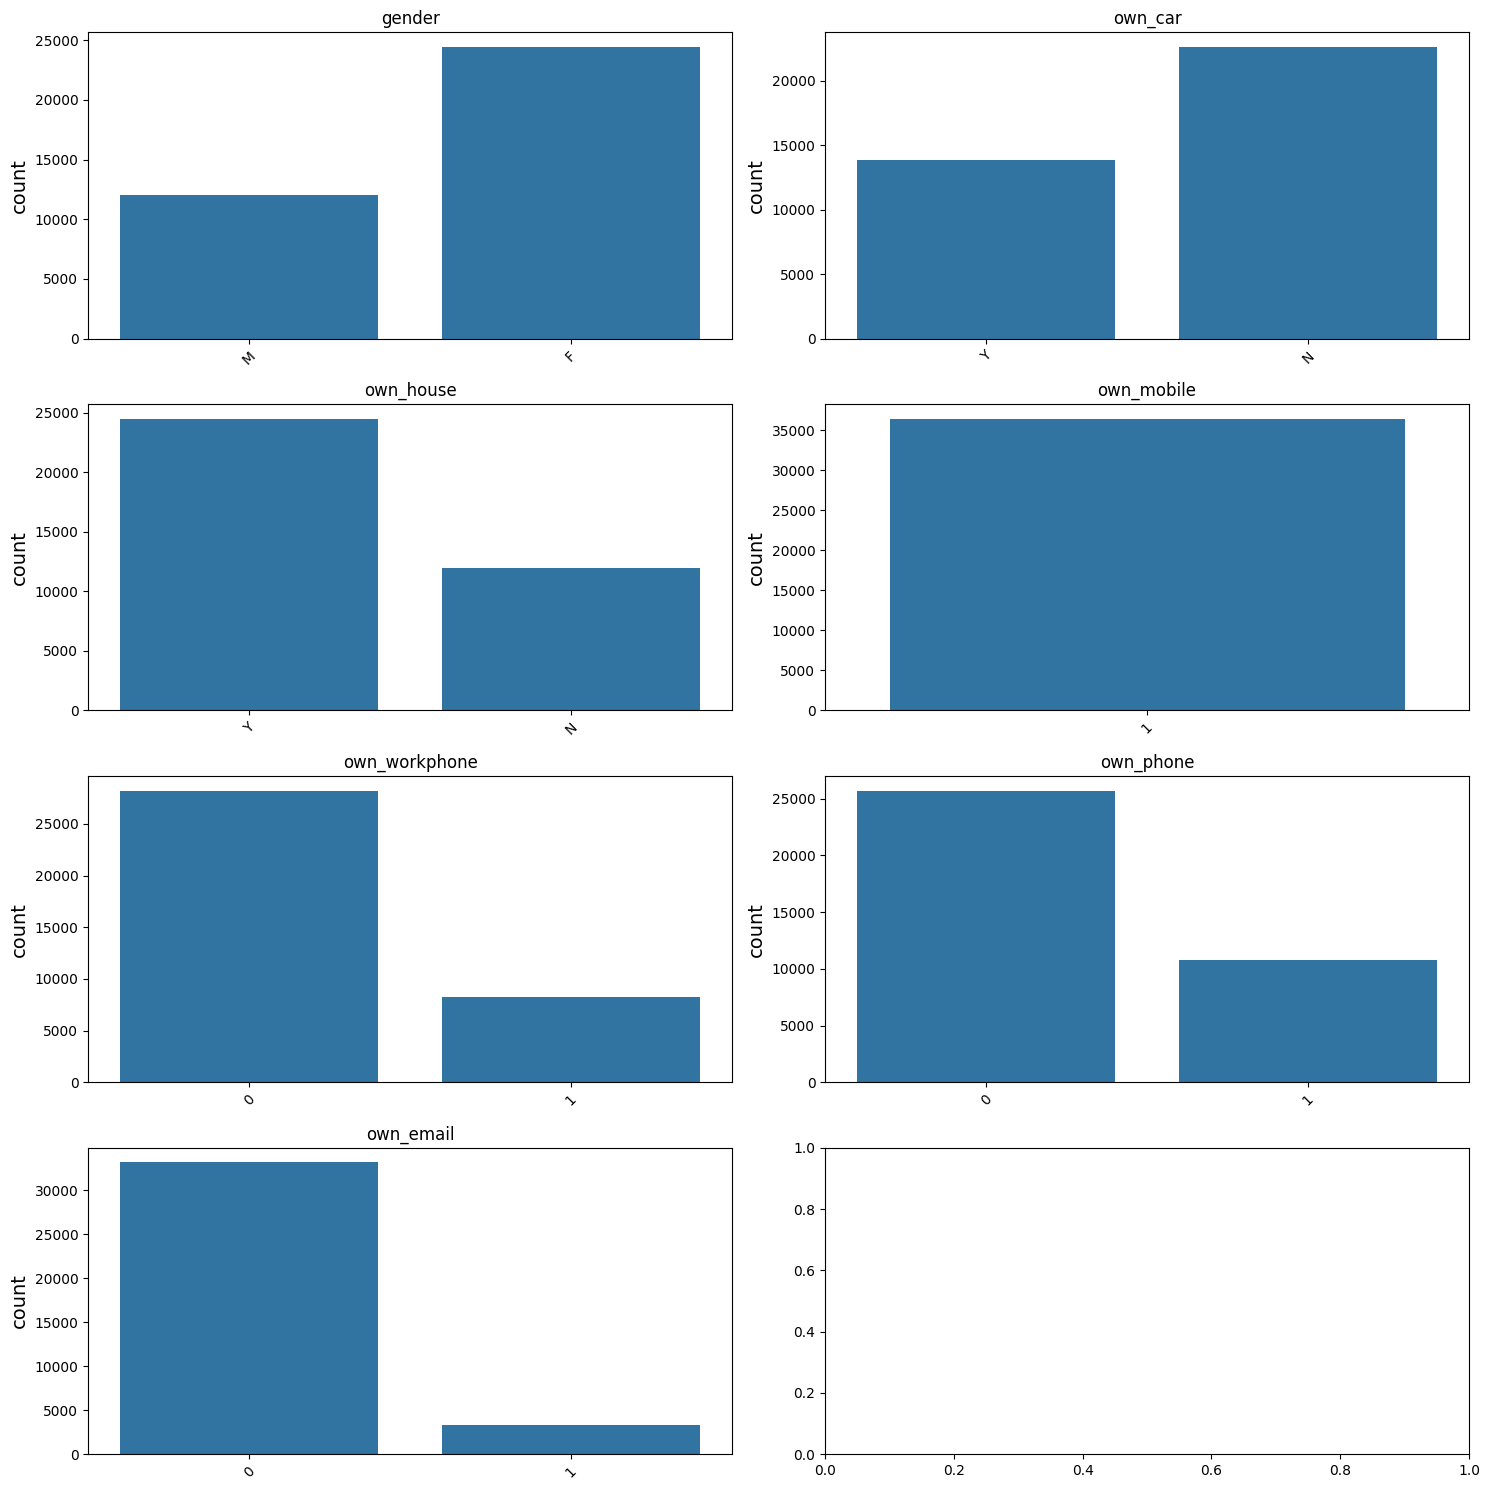

In [79]:

f, axes = plt.subplots(4, 2, figsize=(15, 15))

for i, column in enumerate(binominal_val):
    sns.countplot(data=df, x=column, ax=axes[i//2, i%2])
    axes[i//2, i%2].set_title(column)  # 각 subplot에 제목 설정
    axes[i//2, i%2].set_xlabel('')
    axes[i//2, i%2].tick_params(axis='x', rotation=45)  # x축 눈금 회전

plt.tight_layout()  # 서브플롯 간의 간격 조정
# plt.savefig('image/binominal.png')
plt.show()

In [80]:
# 특이사항

df['own_mobile'].value_counts()
# 전부 휴대폰 소유

own_mobile
1    36457
Name: count, dtype: int64

In [81]:
#  job - na 값 다수 존재
df['job'].isnull().sum()

11323

In [82]:
# own_mobil / job / ID변수 드랍

drop_val = ['own_mobile', 'job', 'ID']

df.drop(columns=drop_val,  inplace=True)

In [83]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36457 entries, 0 to 36456
Data columns (total 18 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   gender         36457 non-null  object 
 1   own_car        36457 non-null  object 
 2   own_house      36457 non-null  object 
 3   children       36457 non-null  int64  
 4   inc            36457 non-null  float64
 5   employment     36457 non-null  object 
 6   edu            36457 non-null  object 
 7   marry          36457 non-null  object 
 8   house_type     36457 non-null  object 
 9   age            36457 non-null  float64
 10  employ_length  36457 non-null  float64
 11  own_workphone  36457 non-null  int64  
 12  own_phone      36457 non-null  int64  
 13  own_email      36457 non-null  int64  
 14  family         36457 non-null  float64
 15  over30         36457 non-null  int32  
 16  over60         36457 non-null  int32  
 17  over90         36457 non-null  int32  
dtypes: flo

In [84]:
# onehot encoding

In [85]:
binominal_val = [val for val in binominal_val if val not in drop_val]
cateorical_val = [val for val in cateorical_val if val not in drop_val]

In [86]:
df = pd.get_dummies(df, columns=cateorical_val, dtype='int')
df = pd.get_dummies(df, columns=binominal_val, dtype='int')
df.head()

,children,inc,age,employ_length,family,over30,over60,over90,edu_Academic degree,edu_Higher education,...,own_car_N,own_car_Y,own_house_N,own_house_Y,own_workphone_0,own_workphone_1,own_phone_0,own_phone_1,own_email_0,own_email_1
0,0,18.705565,32.0,5.023881,2.0,1,0,0,0,1,...,0,1,0,1,0,1,1,0,1,0
1,0,18.705565,32.0,5.023881,2.0,1,0,0,0,1,...,0,1,0,1,0,1,1,0,1,0
2,0,16.779565,58.0,3.637586,2.0,0,0,0,0,0,...,0,1,0,1,1,0,1,0,1,0
3,0,18.042600,52.0,4.624973,1.0,0,0,0,0,0,...,1,0,0,1,1,0,0,1,0,1
4,0,18.042600,52.0,4.624973,1.0,0,0,0,0,0,...,1,0,0,1,1,0,0,1,0,1


In [87]:
def delete_outlier(df, features):
        
    for column in features:
    
        outlier_list = []

        # 1st quartile (25%)
        Q1 = np.percentile(df[column], 25)
        # 3rd quartile (75%)
        Q3 = np.percentile(df[column], 75)
        # Interquartile range (IQR)
        IQR = Q3 - Q1
        # outlier step
        outlier_step = 1.5 * IQR
        # Determining a list of indices of outliers
        outlier_list_column = df[(df[column] < Q1 - outlier_step) | (df[column] > Q3 + outlier_step )].index
        # appending the list of outliers 
        outlier_list.extend(outlier_list_column)

        # Remove duplicates in the outlier_list
        outlier_list = list(set(outlier_list))

        # Drop outliers
        df.drop(outlier_list, inplace=True)

In [88]:
outlier_feature = set()
outlier_feature.add('employ_length')
outlier_feature.add('inc')
outlier_feature.add('age')

In [89]:
df_out = df.copy()
delete_outlier(df_out, outlier_feature)

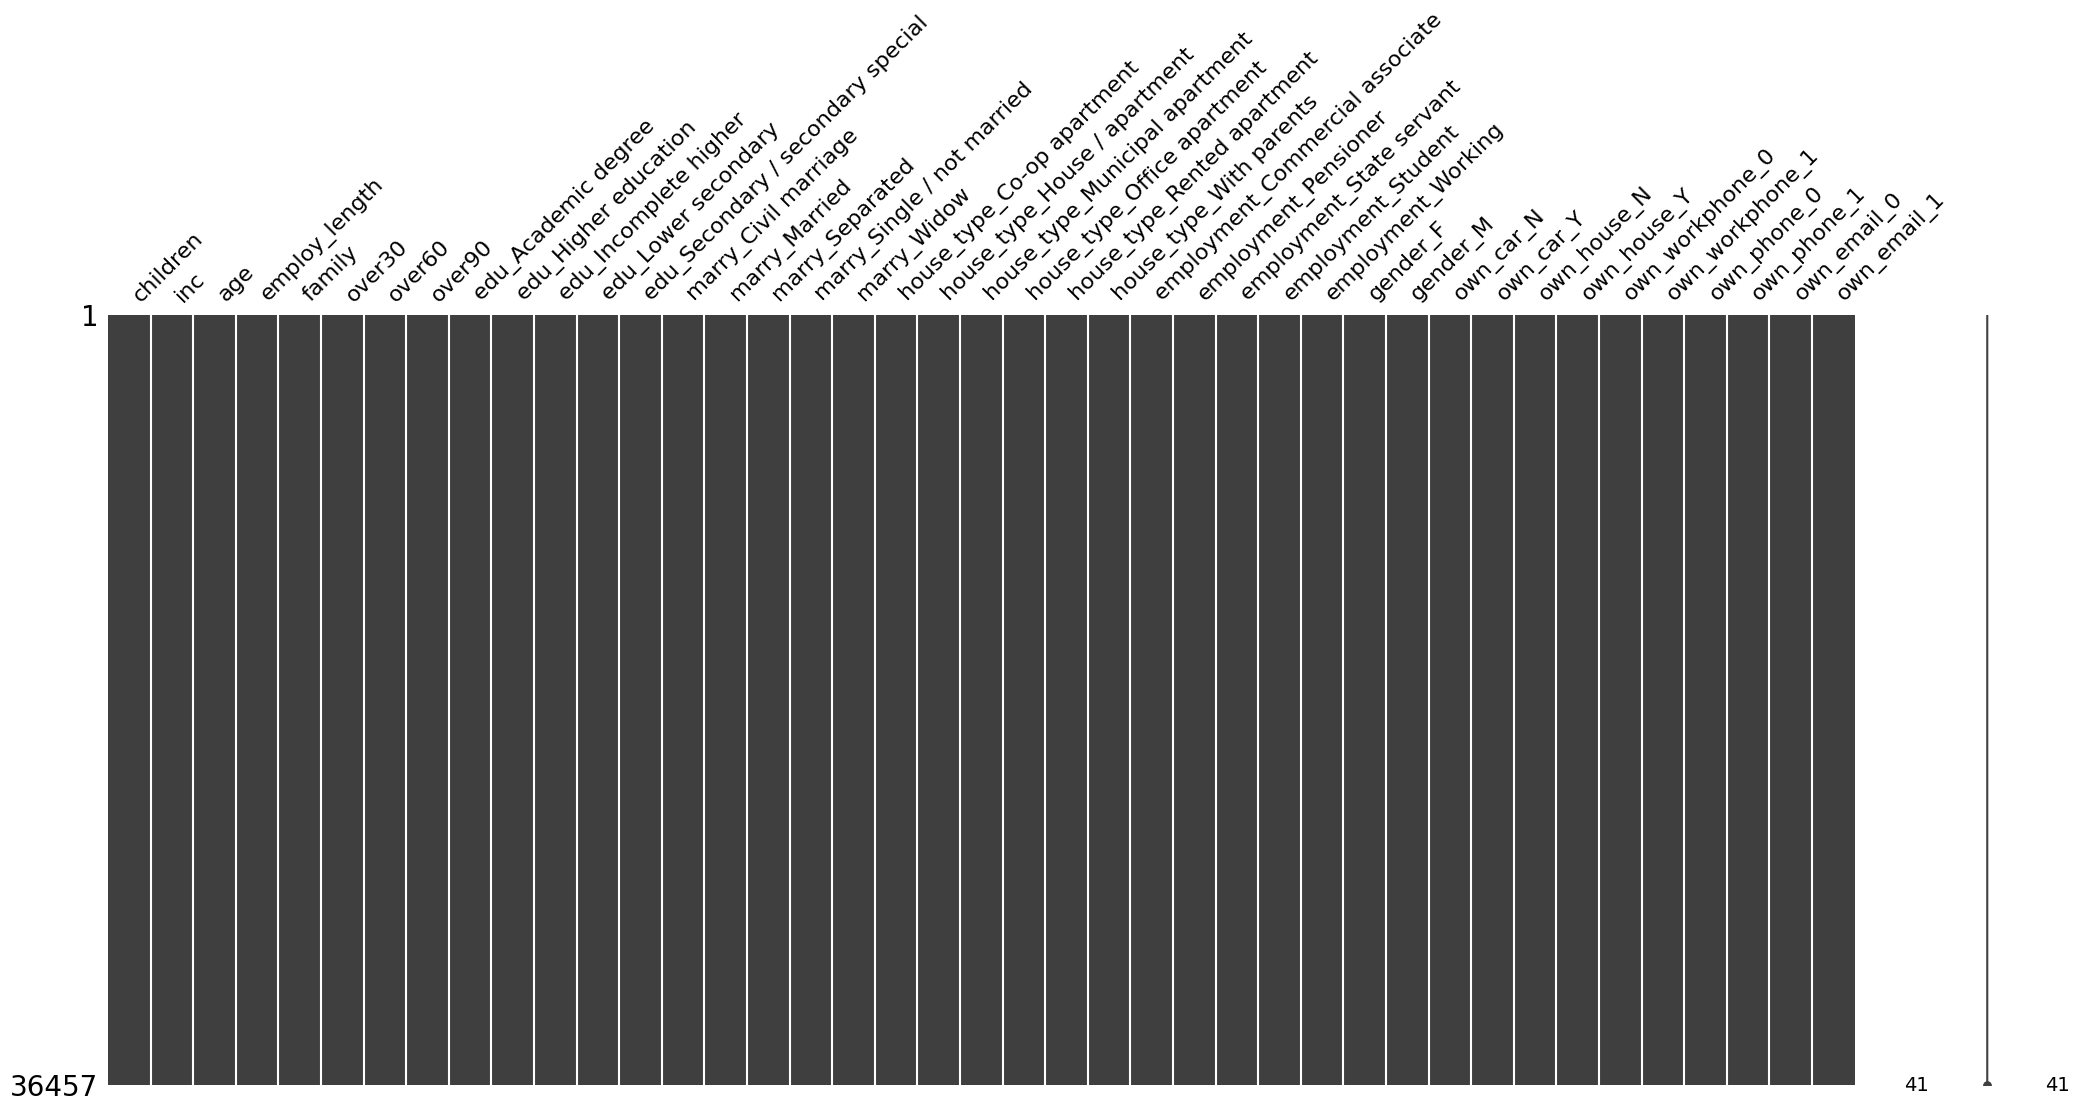

In [90]:
missingno.matrix(df)
plt.show()

In [91]:
###

df['over30'].value_counts()

over30
0    32166
1     4291
Name: count, dtype: int64

In [92]:
df['over60'].value_counts()

over60
0    35841
1      616
Name: count, dtype: int64

In [93]:
X = df_out.drop(columns=['over30', 'over60', 'over90'])
y = df_out['over90']

In [94]:
from imblearn.over_sampling import SMOTE
sm2 = SMOTE(sampling_strategy=0.1, random_state=SEED)
X, y = sm2.fit_resample(X, y)

In [95]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=SEED)
X_train.shape, X_test.shape, y_train.shape, y_test.shape

((31304, 38), (7826, 38), (31304,), (7826,))

In [96]:
X.columns

Index(['children', 'inc', 'age', 'employ_length', 'family',
       'edu_Academic degree', 'edu_Higher education', 'edu_Incomplete higher',
       'edu_Lower secondary', 'edu_Secondary / secondary special',
       'marry_Civil marriage', 'marry_Married', 'marry_Separated',
       'marry_Single / not married', 'marry_Widow',
       'house_type_Co-op apartment', 'house_type_House / apartment',
       'house_type_Municipal apartment', 'house_type_Office apartment',
       'house_type_Rented apartment', 'house_type_With parents',
       'employment_Commercial associate', 'employment_Pensioner',
       'employment_State servant', 'employment_Student', 'employment_Working',
       'gender_F', 'gender_M', 'own_car_N', 'own_car_Y', 'own_house_N',
       'own_house_Y', 'own_workphone_0', 'own_workphone_1', 'own_phone_0',
       'own_phone_1', 'own_email_0', 'own_email_1'],
      dtype='object')

In [97]:
from imblearn.over_sampling import SMOTE
sm = SMOTE(random_state= SEED)
X_resampled, y_resampled = sm.fit_resample(X_train, y_train)

In [98]:
X_resampled.shape, len(y_resampled)

((56916, 38), 56916)

In [99]:
y_test.value_counts()

over90
0    7115
1     711
Name: count, dtype: int64

In [100]:
y_train.value_counts()

over90
0    28458
1     2846
Name: count, dtype: int64

In [101]:
y_resampled.value_counts()


over90
0    28458
1    28458
Name: count, dtype: int64

In [102]:
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# 로지스틱 회귀 분류기로 파이프라인 구성
lr_pipe = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: StandardScaler for feature scaling
    ('lr', LogisticRegression(random_state=SEED))  # Step 2: lr Regression Classifier
])

# 파이프라인을 사용하여 학습
lr_pipe.fit(X_resampled, y_resampled)

# 훈련 정확도 출력
train_score = lr_pipe.score(X_resampled, y_resampled)
print("Training Accuracy:", train_score)

Training Accuracy: 0.8749385058682971


In [103]:
lr_pipe.score(X_test, y_test)

0.962816253513928

In [104]:
y_test.value_counts()

over90
0    7115
1     711
Name: count, dtype: int64

In [105]:
from sklearn.metrics import f1_score, roc_curve, auc
import matplotlib.pyplot as plt


# F1 score 계산
y_pred_train = lr_pipe.predict(X_resampled)
f1_train = f1_score(y_resampled, y_pred_train)
print("Training F1 Score:", f1_train)

y_pred_test = lr_pipe.predict(X_test)
f1_test = f1_score(y_pred_test, y_test)
print("Test F1 Score:", f1_test)

Training F1 Score: 0.8593336231769495
Test F1 Score: 0.7783701447067783


In [106]:
from xgboost import XGBClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

xgb_pipe = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: StandardScaler for feature scaling
    ('xgb', XGBClassifier(random_state=SEED))  # Step 2: XGBoost Classifier
])

xgb_pipe.fit(X_resampled, y_resampled)
train_score = xgb_pipe.score(X_resampled, y_resampled)
print("Training Accuracy:", train_score)

Training Accuracy: 0.9953440157424978


In [107]:
xgb_pipe.score(X_test, y_test)

0.9901610017889088

In [108]:
from sklearn.metrics import f1_score, roc_curve, auc
import matplotlib.pyplot as plt


# F1 score 계산
y_pred_train = xgb_pipe.predict(X_resampled)
f1_train = f1_score(y_resampled, y_pred_train)
print("Training F1 Score:", f1_train)

y_pred_test = xgb_pipe.predict(X_test)
f1_test = f1_score(y_pred_test, y_test)
print("Test F1 Score:", f1_test)



Training F1 Score: 0.9953473673121829
Test F1 Score: 0.9461161651504548


In [109]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler

# Random Forest 분류기로 파이프라인 구성
rf_pipe = Pipeline([
    ('scaler', StandardScaler()),  # Step 1: StandardScaler for feature scaling
    ('rf', RandomForestClassifier(random_state=SEED))  # Step 2: Random Forest Classifier
])

# 파이프라인을 사용하여 학습
rf_pipe.fit(X_resampled, y_resampled)

# 훈련 정확도 출력
train_score = rf_pipe.score(X_resampled, y_resampled)
print("Training Accuracy:", train_score)

Training Accuracy: 0.9962927823459132


In [110]:
rf_pipe.score(X_test, y_test)

0.9897776641962689

In [111]:
from sklearn.metrics import f1_score, roc_curve, auc
import matplotlib.pyplot as plt


# F1 score 계산
y_pred_train = rf_pipe.predict(X_resampled)
f1_train = f1_score(y_resampled, y_pred_train)
print("Training F1 Score:", f1_train)

y_pred_test = rf_pipe.predict(X_test)
f1_test = f1_score(y_pred_test, y_test)
print("Test F1 Score:", f1_test)


Training F1 Score: 0.9962976610341984
Test F1 Score: 0.9438990182328191
